# Heat Exchanger Thermal-Hydraulic Design with NeqSim

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/HeatExchanger_ThermalHydraulicDesign.ipynb)

This notebook demonstrates NeqSim's **shell-and-tube heat exchanger thermal-hydraulic design** capabilities, including:

1. **Tube-side & shell-side heat transfer coefficients** (Gnielinski, Kern, Bell-Delaware)
2. **Overall heat transfer coefficient U** with fouling and tube-wall resistance
3. **Pressure drop calculations** for both sides
4. **LMTD correction factors** for multi-pass exchangers
5. **Flow-induced vibration screening** per TEMA RCB-4.6
6. **Sensitivity analysis** — effects of geometry and flow on performance
7. **Rating mode** — computing U from correlations within a process simulation
8. **Full mechanical design integration** with automated type selection

## Architecture

```
ThermalDesignCalculator ─── BellDelawareMethod (shell-side J-factors)
        │                └── LMTDcorrectionFactor (Ft for multi-pass)
        │                └── VibrationAnalysis (TEMA RCB-4.6)
        │
        └── Integrated into ShellAndTubeDesignCalculator
                └── HeatExchangerMechanicalDesign (full sizing)
                        └── HeatExchanger (RATING mode)
```

In [1]:
# Setup and imports
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

import jpype
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load NeqSim thermal design classes via jpype
ThermalDesignCalculator = jpype.JClass("neqsim.process.mechanicaldesign.heatexchanger.ThermalDesignCalculator")
BellDelawareMethod = jpype.JClass("neqsim.process.mechanicaldesign.heatexchanger.BellDelawareMethod")
LMTDcorrectionFactor = jpype.JClass("neqsim.process.mechanicaldesign.heatexchanger.LMTDcorrectionFactor")
VibrationAnalysis = jpype.JClass("neqsim.process.mechanicaldesign.heatexchanger.VibrationAnalysis")

# Process simulation classes
if NEQSIM_MODE == "devtools":
    SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
    Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
    HeatExchanger = jpype.JClass("neqsim.process.equipment.heatexchanger.HeatExchanger")
    ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
else:
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    Stream = jneqsim.process.equipment.stream.Stream
    HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
    ProcessSystem = jneqsim.process.processmodel.ProcessSystem

plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6)})
print("All classes loaded successfully.")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.6.1.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)
All classes loaded successfully.


## 1. Standalone Thermal-Hydraulic Calculation

We start with a standalone calculation for a gas cooler — a hot process gas on the shell side
cooled by water on the tube side. This is the simplest way to use the `ThermalDesignCalculator`.

**Exchanger geometry:**
- 100 tubes, 3/4" OD × 16 BWG (19.05 mm OD, 14.83 mm ID)
- 6.1 m tube length, 2 tube passes
- 500 mm shell ID, triangular pitch (23.81 mm)
- 10 segmental baffles at 200 mm spacing, 25% baffle cut

In [2]:
# Create thermal design calculator
calc = ThermalDesignCalculator()

# -- Geometry --
calc.setTubeODm(0.01905)       # 3/4" OD
calc.setTubeIDm(0.01483)       # 16 BWG wall
calc.setTubeLengthm(6.096)     # ~20 ft
calc.setTubeCount(100)
calc.setTubePasses(2)
calc.setTubePitchm(0.02381)    # 1.25 * OD triangular
calc.setTriangularPitch(True)
calc.setShellIDm(0.5)          # 500 mm shell
calc.setBaffleSpacingm(0.2)    # 200 mm
calc.setBaffleCount(10)
calc.setBaffleCut(0.25)        # 25%

# -- Tube-side fluid: cooling water --
#   density=998 kg/m3, viscosity=0.001 Pa·s, Cp=4180 J/(kg·K), k=0.60 W/(m·K)
#   mass flow = 5 kg/s, being heated
calc.setTubeSideFluid(998.0, 0.001, 4180.0, 0.60, 5.0, True)

# -- Shell-side fluid: process gas (hydrocarbon) --
#   density=50 kg/m3, viscosity=1.5e-5 Pa·s, Cp=2200 J/(kg·K), k=0.03 W/(m·K)
#   mass flow = 3 kg/s
calc.setShellSideFluid(50.0, 1.5e-5, 2200.0, 0.03, 3.0)

# -- Fouling --
calc.setFoulingTube(0.00018)    # treated cooling water
calc.setFoulingShell(0.00035)   # light hydrocarbons

# Run calculation
calc.calculate()

# Extract results
results_map = calc.toMap()

# Display key results
print("=" * 60)
print("THERMAL-HYDRAULIC DESIGN RESULTS")
print("=" * 60)
print(f"\n--- Heat Transfer Coefficients ---")
print(f"  Tube-side HTC:     {float(calc.getTubeSideHTC()):>10.1f} W/(m²·K)")
print(f"  Shell-side HTC:    {float(calc.getShellSideHTC()):>10.1f} W/(m²·K)")
print(f"  Overall U:         {float(calc.getOverallU()):>10.1f} W/(m²·K)")
print(f"\n--- Pressure Drops ---")
print(f"  Tube-side ΔP:      {float(calc.getTubeSidePressureDropBar()):>10.4f} bar")
print(f"  Shell-side ΔP:     {float(calc.getShellSidePressureDropBar()):>10.4f} bar")
print(f"\n--- Flow Parameters ---")
print(f"  Tube-side velocity: {float(calc.getTubeSideVelocity()):>9.2f} m/s")
print(f"  Shell-side velocity:{float(calc.getShellSideVelocity()):>9.2f} m/s")
print(f"  Tube-side Re:       {float(calc.getTubeSideRe()):>9.0f}")
print(f"  Shell-side Re:      {float(calc.getShellSideRe()):>9.0f}")

THERMAL-HYDRAULIC DESIGN RESULTS

--- Heat Transfer Coefficients ---
  Tube-side HTC:         2752.9 W/(m²·K)
  Shell-side HTC:         543.1 W/(m²·K)
  Overall U:              340.7 W/(m²·K)

--- Pressure Drops ---
  Tube-side ΔP:          0.0530 bar
  Shell-side ΔP:         0.0319 bar

--- Flow Parameters ---
  Tube-side velocity:      0.58 m/s
  Shell-side velocity:     3.00 m/s
  Tube-side Re:            8586
  Shell-side Re:         137702


## 2. Kern vs Bell-Delaware Shell-Side Method Comparison

The calculator supports two shell-side methods:
- **Kern**: Simple equivalent-diameter approach — good for preliminary sizing
- **Bell-Delaware**: Detailed J-factor corrections for baffle leakage, bypass, window flow, etc.

Let's compare both across a range of shell-side flow rates.

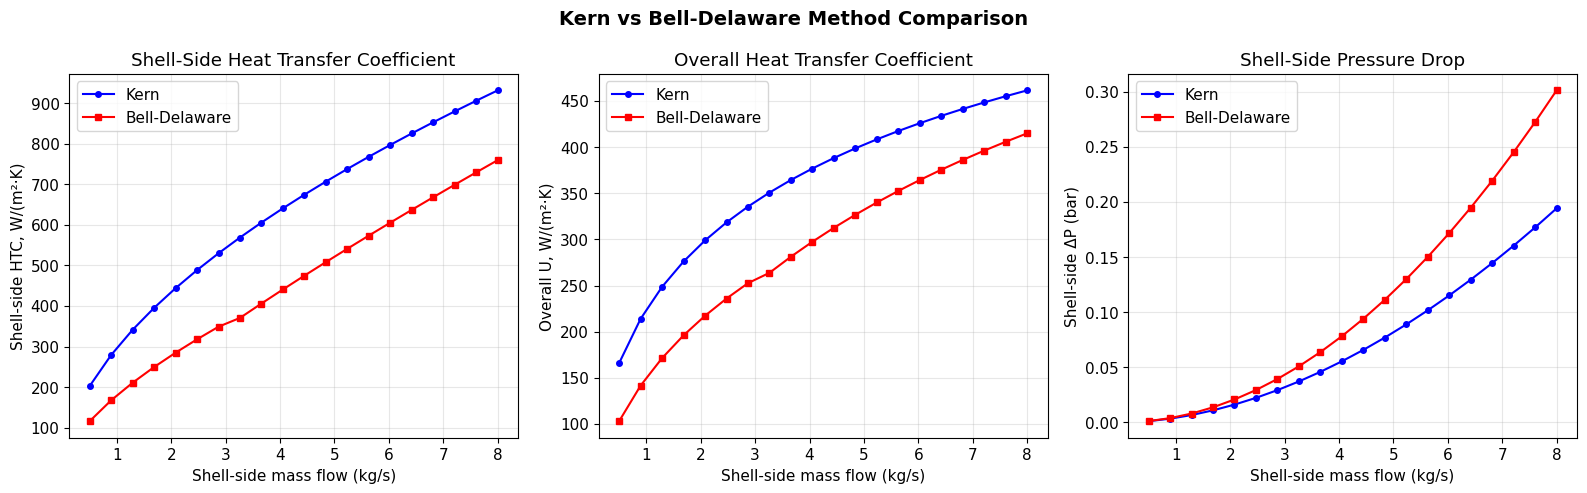


Kern vs Bell-Delaware Comparison (selected points):
 Shell Flow (kg/s) Kern h_s (W/m²K) B-D h_s (W/m²K) Kern U (W/m²K) B-D U (W/m²K)
          0.500000            202.7           116.1          165.9         103.0
          2.473684            488.4           317.8          318.4         235.8
          4.447368            674.4           474.8          388.1         312.5
          6.421053            825.4           637.0          433.8         375.4


In [3]:
# Sweep shell-side mass flow rate from 0.5 to 8 kg/s
shell_flows = np.linspace(0.5, 8.0, 20)
kern_U = []
bd_U = []
kern_hs = []
bd_hs = []
kern_dp = []
bd_dp = []

ShellSideMethod = jpype.JClass("neqsim.process.mechanicaldesign.heatexchanger.ThermalDesignCalculator$ShellSideMethod")

for mdot in shell_flows:
    c = ThermalDesignCalculator()
    c.setTubeODm(0.01905); c.setTubeIDm(0.01483); c.setTubeLengthm(6.096)
    c.setTubeCount(100); c.setTubePasses(2); c.setTubePitchm(0.02381)
    c.setTriangularPitch(True); c.setShellIDm(0.5)
    c.setBaffleSpacingm(0.2); c.setBaffleCount(10); c.setBaffleCut(0.25)
    c.setTubeSideFluid(998.0, 0.001, 4180.0, 0.60, 5.0, True)
    c.setShellSideFluid(50.0, 1.5e-5, 2200.0, 0.03, float(mdot))
    c.setFoulingTube(0.00018); c.setFoulingShell(0.00035)

    # Kern method
    c.setShellSideMethod(ShellSideMethod.KERN)
    c.calculate()
    kern_U.append(float(c.getOverallU()))
    kern_hs.append(float(c.getShellSideHTC()))
    kern_dp.append(float(c.getShellSidePressureDropBar()))

    # Bell-Delaware method
    c.setShellSideMethod(ShellSideMethod.BELL_DELAWARE)
    c.calculate()
    bd_U.append(float(c.getOverallU()))
    bd_hs.append(float(c.getShellSideHTC()))
    bd_dp.append(float(c.getShellSidePressureDropBar()))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(shell_flows, kern_hs, 'b-o', markersize=4, label='Kern')
axes[0].plot(shell_flows, bd_hs, 'r-s', markersize=4, label='Bell-Delaware')
axes[0].set_xlabel('Shell-side mass flow (kg/s)')
axes[0].set_ylabel('Shell-side HTC, W/(m²·K)')
axes[0].set_title('Shell-Side Heat Transfer Coefficient')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(shell_flows, kern_U, 'b-o', markersize=4, label='Kern')
axes[1].plot(shell_flows, bd_U, 'r-s', markersize=4, label='Bell-Delaware')
axes[1].set_xlabel('Shell-side mass flow (kg/s)')
axes[1].set_ylabel('Overall U, W/(m²·K)')
axes[1].set_title('Overall Heat Transfer Coefficient')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(shell_flows, kern_dp, 'b-o', markersize=4, label='Kern')
axes[2].plot(shell_flows, bd_dp, 'r-s', markersize=4, label='Bell-Delaware')
axes[2].set_xlabel('Shell-side mass flow (kg/s)')
axes[2].set_ylabel('Shell-side ΔP (bar)')
axes[2].set_title('Shell-Side Pressure Drop')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Kern vs Bell-Delaware Method Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("kern_vs_bell_delaware.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
df = pd.DataFrame({
    'Shell Flow (kg/s)': shell_flows,
    'Kern h_s (W/m²K)': [f"{v:.1f}" for v in kern_hs],
    'B-D h_s (W/m²K)': [f"{v:.1f}" for v in bd_hs],
    'Kern U (W/m²K)': [f"{v:.1f}" for v in kern_U],
    'B-D U (W/m²K)': [f"{v:.1f}" for v in bd_U],
})
print("\nKern vs Bell-Delaware Comparison (selected points):")
print(df.iloc[::5].to_string(index=False))

### Discussion — Kern vs Bell-Delaware

**Observation:** The Kern method consistently predicts higher shell-side HTCs than Bell-Delaware, especially at higher flow rates. The overall U converges somewhat because the tube-side resistance remains constant.

**Physical mechanism:** The Bell-Delaware method accounts for real-world inefficiencies — baffle leakage (J_l), bundle bypass (J_b), and window effects (J_c) — that reduce effective heat transfer. Kern's equivalent-diameter approach does not capture these.

**Engineering implication:** Using Kern alone for final design can lead to undersized exchangers. Bell-Delaware is the industry standard for detailed design and should be used for equipment specification.

**Recommendation:** Use Kern for preliminary screening and Bell-Delaware for final design. If the two methods differ by more than 30%, investigate baffle geometry carefully.

## 3. LMTD Correction Factor Analysis

For multi-pass heat exchangers, the effective mean temperature difference is reduced by the correction factor F_t. This section explores how F_t varies with thermal effectiveness P for different capacity ratios R and shell-pass configurations.

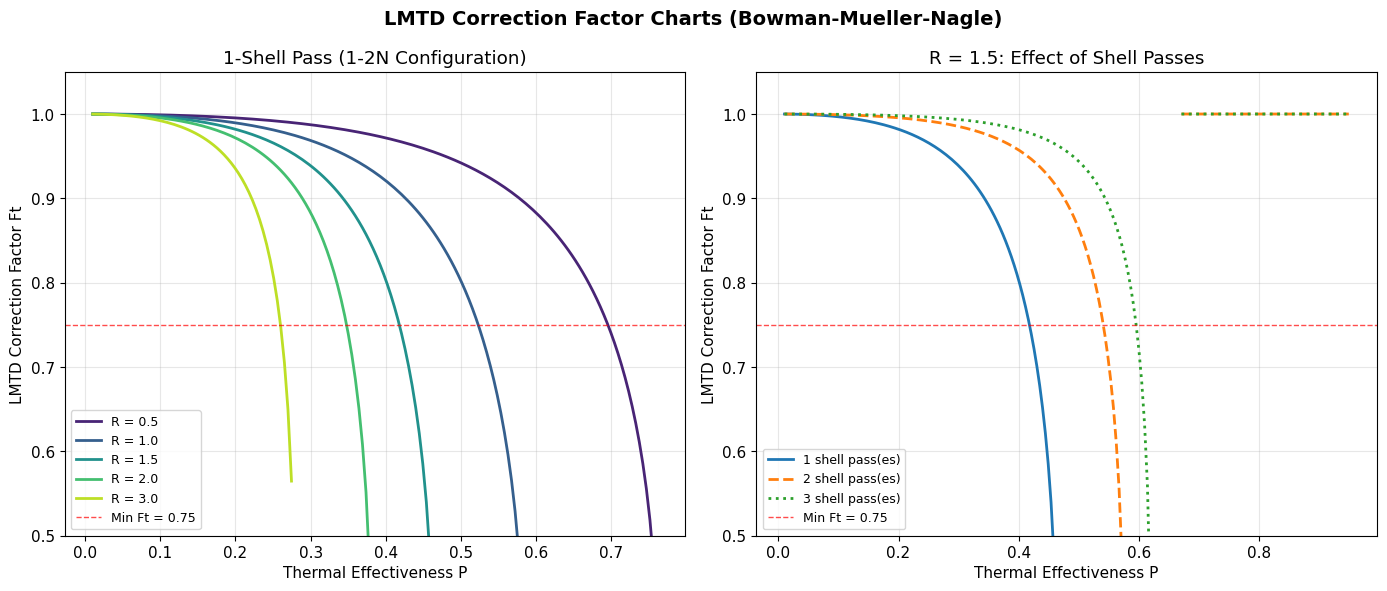


--- Practical LMTD Correction Example ---
Hot side: 150°C → 90°C, Cold side: 30°C → 80°C
  R = 1.200,  P = 0.417
  Ft (1 shell pass) = 0.8669
  Ft (2 shell passes) = 0.9695

High-effectiveness case: Hot 200°C → 50°C, Cold 30°C → 170°C
  Required shell passes for Ft >= 0.75: 6


In [4]:
# LMTD correction factor plots: Ft vs P for different R values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: 1-shell pass, various R ---
R_values = [0.5, 1.0, 1.5, 2.0, 3.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(R_values)))

for R_val, col in zip(R_values, colors):
    P_range = np.linspace(0.01, 0.95, 200)
    Ft_vals = []
    for P_val in P_range:
        try:
            ft = float(LMTDcorrectionFactor.calcFtFromRP(float(R_val), float(P_val), 1))
            if ft > 0.3 and ft <= 1.0:
                Ft_vals.append(ft)
            else:
                Ft_vals.append(np.nan)
        except Exception:
            Ft_vals.append(np.nan)

    axes[0].plot(P_range, Ft_vals, color=col, linewidth=2, label=f'R = {R_val}')

axes[0].axhline(y=0.75, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Min Ft = 0.75')
axes[0].set_xlabel('Thermal Effectiveness P')
axes[0].set_ylabel('LMTD Correction Factor Ft')
axes[0].set_title('1-Shell Pass (1-2N Configuration)')
axes[0].set_ylim(0.5, 1.05)
axes[0].legend(loc='lower left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Fixed R=1.5, different shell passes ---
shell_passes = [1, 2, 3]
styles = ['-', '--', ':']

for n_pass, style in zip(shell_passes, styles):
    P_range = np.linspace(0.01, 0.95, 200)
    Ft_vals = []
    for P_val in P_range:
        try:
            ft = float(LMTDcorrectionFactor.calcFtFromRP(1.5, float(P_val), n_pass))
            if ft > 0.3 and ft <= 1.0:
                Ft_vals.append(ft)
            else:
                Ft_vals.append(np.nan)
        except Exception:
            Ft_vals.append(np.nan)

    axes[1].plot(P_range, Ft_vals, linewidth=2, linestyle=style,
                 label=f'{n_pass} shell pass(es)')

axes[1].axhline(y=0.75, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Min Ft = 0.75')
axes[1].set_xlabel('Thermal Effectiveness P')
axes[1].set_ylabel('LMTD Correction Factor Ft')
axes[1].set_title('R = 1.5: Effect of Shell Passes')
axes[1].set_ylim(0.5, 1.05)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('LMTD Correction Factor Charts (Bowman-Mueller-Nagle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("lmtd_correction_factor.png", dpi=150, bbox_inches="tight")
plt.show()

# Practical example
print("\n--- Practical LMTD Correction Example ---")
print("Hot side: 150°C → 90°C, Cold side: 30°C → 80°C")
R = float(LMTDcorrectionFactor.calcR(150.0, 90.0, 30.0, 80.0))
P = float(LMTDcorrectionFactor.calcP(150.0, 90.0, 30.0, 80.0))
Ft1 = float(LMTDcorrectionFactor.calcFt1ShellPass(150.0, 90.0, 30.0, 80.0))
Ft2 = float(LMTDcorrectionFactor.calcFt(150.0, 90.0, 30.0, 80.0, 2))
print(f"  R = {R:.3f},  P = {P:.3f}")
print(f"  Ft (1 shell pass) = {Ft1:.4f}")
print(f"  Ft (2 shell passes) = {Ft2:.4f}")

# Temperature cross / high-P case
print("\nHigh-effectiveness case: Hot 200°C → 50°C, Cold 30°C → 170°C")
passes_needed = int(LMTDcorrectionFactor.requiredShellPasses(200.0, 50.0, 30.0, 170.0))
print(f"  Required shell passes for Ft >= 0.75: {passes_needed}")

### Discussion — LMTD Correction Factor

**Observation:** The Ft factor drops sharply as thermal effectiveness (P) approaches a critical value that depends on R. Higher R (larger capacity ratio) restricts the usable P range for a single shell pass. Adding shell passes dramatically extends the feasible operating region.

**Physical mechanism:** In a 1-2 shell-and-tube exchanger, part of the cold fluid flows co-current with the hot fluid in one tube pass. As P increases, this co-current section becomes a growing thermal penalty, reducing effective ΔT below pure counterflow. Multiple shell passes approximate true counterflow more closely.

**Engineering implication:** When Ft < 0.75, the effective ΔT is so degraded that the required area becomes uneconomical. The `requiredShellPasses()` method automates the selection.

**Recommendation:** Always check Ft during design. If it falls below 0.80, consider adding shell passes or switching to true counterflow (e.g., double-pipe or plate exchanger).

## 4. Effect of Tube Count on Performance

The number of tubes directly affects velocity, HTC, pressure drop, and overall U. Let's sweep tube count to understand these trade-offs and find the optimal design window.

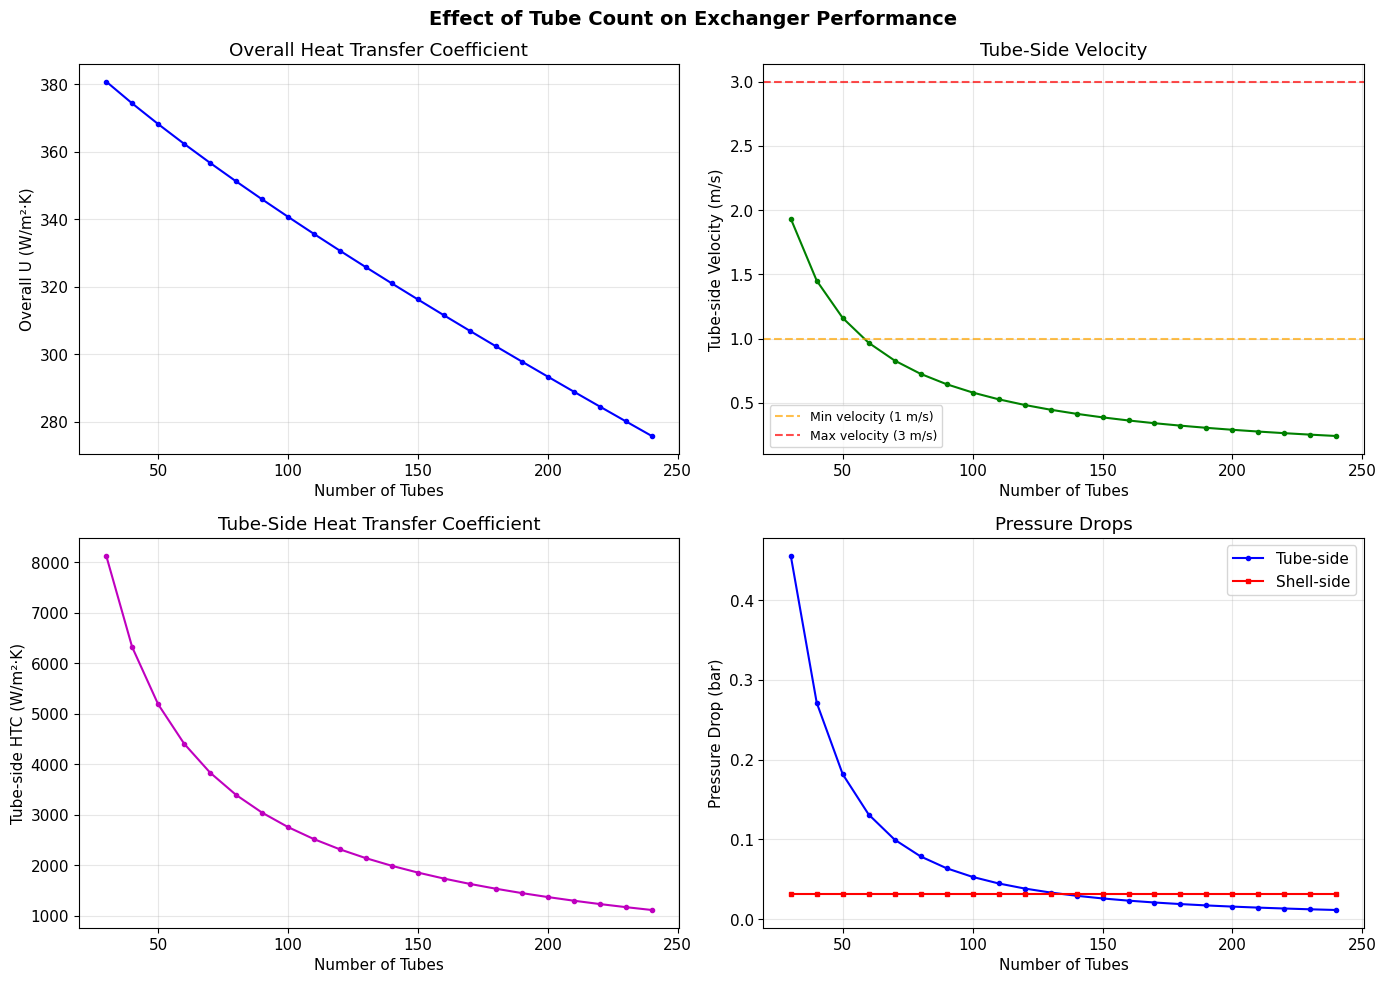

In [5]:
# Tube count sensitivity study
tube_counts = np.arange(30, 250, 10)
res_U = []
res_vt = []
res_dp_tube = []
res_dp_shell = []
res_ht = []

for nt in tube_counts:
    c = ThermalDesignCalculator()
    c.setTubeODm(0.01905); c.setTubeIDm(0.01483); c.setTubeLengthm(6.096)
    c.setTubeCount(int(nt)); c.setTubePasses(2); c.setTubePitchm(0.02381)
    c.setTriangularPitch(True); c.setShellIDm(0.5)
    c.setBaffleSpacingm(0.2); c.setBaffleCount(10); c.setBaffleCut(0.25)
    c.setTubeSideFluid(998.0, 0.001, 4180.0, 0.60, 5.0, True)
    c.setShellSideFluid(50.0, 1.5e-5, 2200.0, 0.03, 3.0)
    c.setFoulingTube(0.00018); c.setFoulingShell(0.00035)
    c.calculate()

    res_U.append(float(c.getOverallU()))
    res_vt.append(float(c.getTubeSideVelocity()))
    res_dp_tube.append(float(c.getTubeSidePressureDropBar()))
    res_dp_shell.append(float(c.getShellSidePressureDropBar()))
    res_ht.append(float(c.getTubeSideHTC()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall U vs tube count
axes[0, 0].plot(tube_counts, res_U, 'b-o', markersize=3)
axes[0, 0].set_xlabel('Number of Tubes')
axes[0, 0].set_ylabel('Overall U (W/m²·K)')
axes[0, 0].set_title('Overall Heat Transfer Coefficient')
axes[0, 0].grid(True, alpha=0.3)

# Tube-side velocity vs tube count
axes[0, 1].plot(tube_counts, res_vt, 'g-o', markersize=3)
axes[0, 1].axhline(y=1.0, color='orange', linestyle='--', alpha=0.7, label='Min velocity (1 m/s)')
axes[0, 1].axhline(y=3.0, color='red', linestyle='--', alpha=0.7, label='Max velocity (3 m/s)')
axes[0, 1].set_xlabel('Number of Tubes')
axes[0, 1].set_ylabel('Tube-side Velocity (m/s)')
axes[0, 1].set_title('Tube-Side Velocity')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Tube-side HTC vs tube count
axes[1, 0].plot(tube_counts, res_ht, 'm-o', markersize=3)
axes[1, 0].set_xlabel('Number of Tubes')
axes[1, 0].set_ylabel('Tube-side HTC (W/m²·K)')
axes[1, 0].set_title('Tube-Side Heat Transfer Coefficient')
axes[1, 0].grid(True, alpha=0.3)

# Pressure drops vs tube count
axes[1, 1].plot(tube_counts, res_dp_tube, 'b-o', markersize=3, label='Tube-side')
axes[1, 1].plot(tube_counts, res_dp_shell, 'r-s', markersize=3, label='Shell-side')
axes[1, 1].set_xlabel('Number of Tubes')
axes[1, 1].set_ylabel('Pressure Drop (bar)')
axes[1, 1].set_title('Pressure Drops')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Effect of Tube Count on Exchanger Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("tube_count_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussion — Tube Count Sensitivity

**Observation:** Increasing tube count dramatically reduces tube-side velocity and HTC. Overall U drops because the tube-side coefficient becomes the controlling resistance. Pressure drop decreases with more tubes due to lower velocities.

**Physical mechanism:** For a fixed tube-side mass flow rate, more tubes means each tube carries less flow, reducing velocity and hence Reynolds number. The Gnielinski correlation gives h ∝ Re^0.8 approximately, so the HTC drops sharply.

**Engineering implication:** There is an optimal tube count that balances heat transfer against pressure drop. Too few tubes → excessive ΔP and potential erosion; too many → poor heat transfer and fouling risk from low velocities.

**Recommendation:** Target tube-side velocity between 1.0–3.0 m/s for water service. The velocity constraint bands in the plot help identify the acceptable tube count range for this exchanger.

## 5. Bell-Delaware J-Factor Breakdown

The Bell-Delaware method applies five correction factors to the ideal crossflow HTC. Let's visualize how each factor varies with its key parameter.

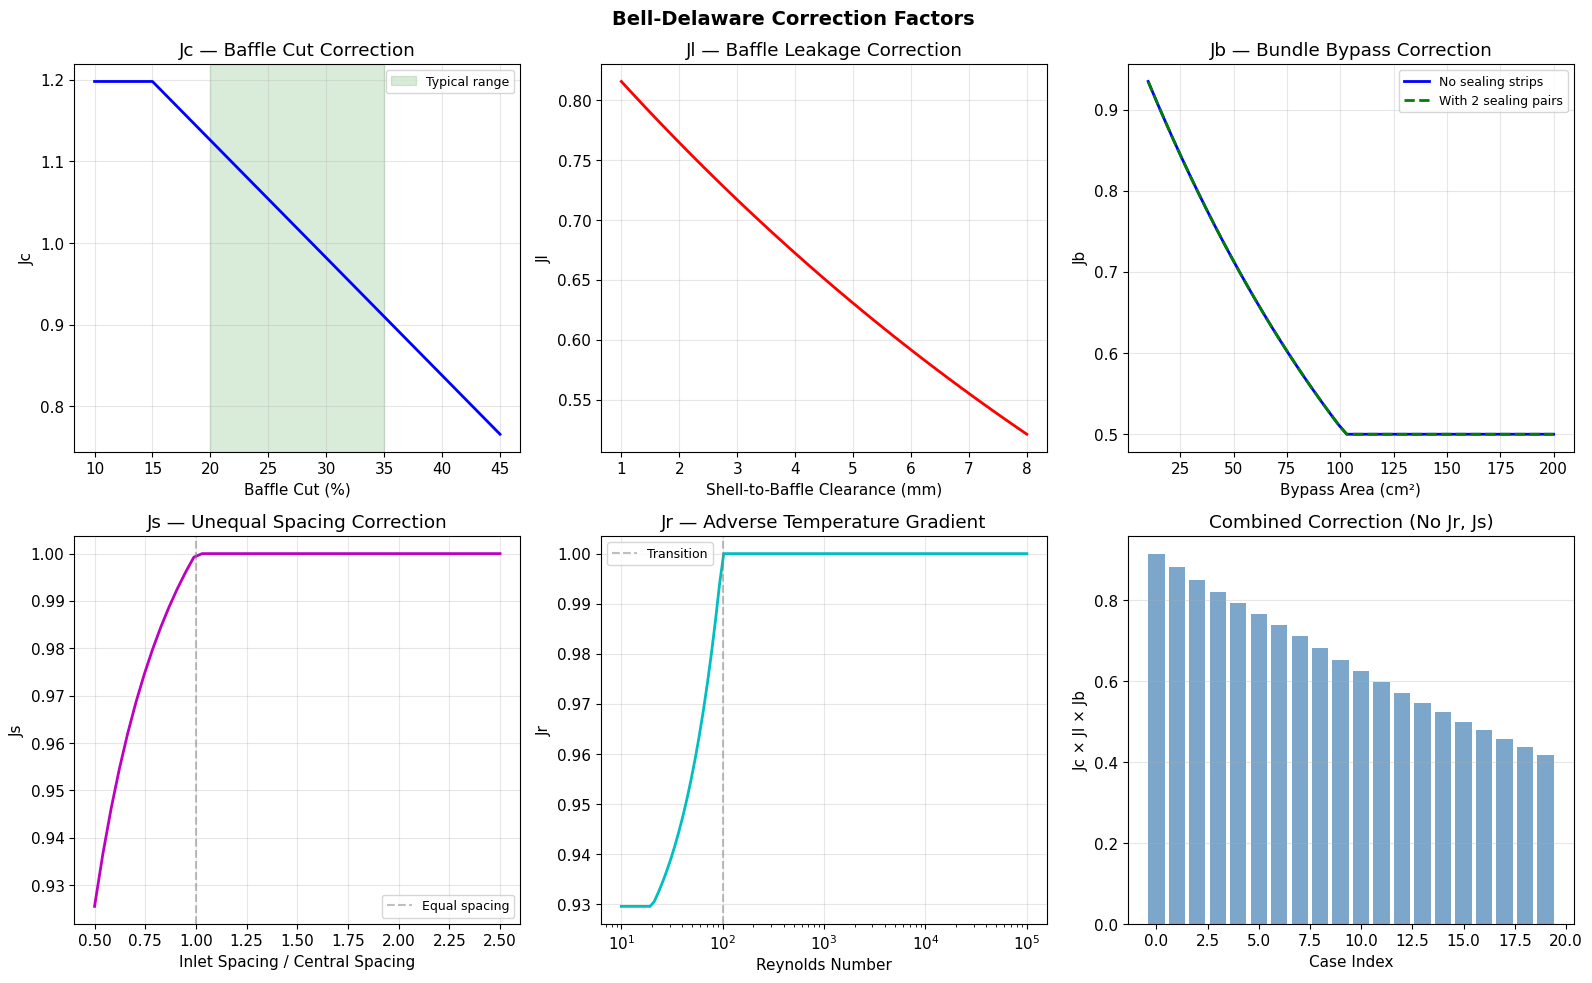

In [6]:
# Bell-Delaware J-factor analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Jc vs baffle cut
baffle_cuts = np.linspace(0.10, 0.45, 50)
jc_vals = [float(BellDelawareMethod.calcJc(float(bc))) for bc in baffle_cuts]
axes[0, 0].plot(baffle_cuts * 100, jc_vals, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Baffle Cut (%)')
axes[0, 0].set_ylabel('Jc')
axes[0, 0].set_title('Jc — Baffle Cut Correction')
axes[0, 0].axvspan(20, 35, alpha=0.15, color='green', label='Typical range')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Jl vs baffle clearance ratio
aCross = float(BellDelawareMethod.calcCrossflowArea(0.5, 0.2, 0.01905, 0.02381))
shell_clearances = np.linspace(0.001, 0.008, 50)
jl_vals = [float(BellDelawareMethod.calcJl(0.0004, float(sc), aCross, 100, 0.01905, 0.2))
           for sc in shell_clearances]
axes[0, 1].plot(shell_clearances * 1000, jl_vals, 'r-', linewidth=2)
axes[0, 1].set_xlabel('Shell-to-Baffle Clearance (mm)')
axes[0, 1].set_ylabel('Jl')
axes[0, 1].set_title('Jl — Baffle Leakage Correction')
axes[0, 1].grid(True, alpha=0.3)

# Jb vs bypass area
bypass_areas = np.linspace(0.001, 0.02, 50)
jb_no_seal = [float(BellDelawareMethod.calcJb(float(ba), aCross, False, 0, 15))
              for ba in bypass_areas]
jb_with_seal = [float(BellDelawareMethod.calcJb(float(ba), aCross, True, 2, 15))
                for ba in bypass_areas]
axes[0, 2].plot(bypass_areas * 1e4, jb_no_seal, 'b-', linewidth=2, label='No sealing strips')
axes[0, 2].plot(bypass_areas * 1e4, jb_with_seal, 'g--', linewidth=2, label='With 2 sealing pairs')
axes[0, 2].set_xlabel('Bypass Area (cm²)')
axes[0, 2].set_ylabel('Jb')
axes[0, 2].set_title('Jb — Bundle Bypass Correction')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3)

# Js vs spacing ratio
inlet_spacings = np.linspace(0.1, 0.5, 50)
js_vals = [float(BellDelawareMethod.calcJs(0.2, float(isp), float(isp), 10))
           for isp in inlet_spacings]
axes[1, 0].plot(inlet_spacings / 0.2, js_vals, 'm-', linewidth=2)
axes[1, 0].set_xlabel('Inlet Spacing / Central Spacing')
axes[1, 0].set_ylabel('Js')
axes[1, 0].set_title('Js — Unequal Spacing Correction')
axes[1, 0].axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal spacing')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Jr vs Re
re_range = np.logspace(1, 5, 100)
jr_vals = [float(BellDelawareMethod.calcJr(float(re), 15)) for re in re_range]
axes[1, 1].semilogx(re_range, jr_vals, 'c-', linewidth=2)
axes[1, 1].set_xlabel('Reynolds Number')
axes[1, 1].set_ylabel('Jr')
axes[1, 1].set_title('Jr — Adverse Temperature Gradient')
axes[1, 1].axvline(x=100, color='gray', linestyle='--', alpha=0.5, label='Transition')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

# Combined product of all J-factors
product_vals = [jc * jl * jb for jc, jl, jb in zip(jc_vals[:20], jl_vals[:20], jb_no_seal[:20])]
axes[1, 2].bar(range(len(product_vals)), product_vals, color='steelblue', alpha=0.7)
axes[1, 2].set_xlabel('Case Index')
axes[1, 2].set_ylabel('Jc × Jl × Jb')
axes[1, 2].set_title('Combined Correction (No Jr, Js)')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Bell-Delaware Correction Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("bell_delaware_jfactors.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussion — Bell-Delaware J-Factors

**Observation:** Each J-factor responds to different geometric parameters. Jl (leakage) is the most impactful in poorly-sealed designs, dropping below 0.4 with large shell-baffle clearances. Jb improves significantly with sealing strips. Jr only matters in laminar flow (Re < 100).

**Physical mechanism:** Real shell-side flow is not pure crossflow — fluid leaks through tube-to-baffle and shell-to-baffle clearances (Jl), bypasses between bundle and shell wall (Jb), and passes through the baffle window (Jc). Each mechanism reduces the effective heat transfer from the ideal tube-bank value.

**Engineering implication:** The dominant penalty in most industrial exchangers is baffle leakage (Jl). Tight manufacturing tolerances and proper baffle-hole sizing are critical. Sealing strips provide a simple retrofit to recover bypass losses.

**Recommendation:** Specify tight shell-to-baffle clearances (< 3 mm) and at least 1 pair of sealing strips per 5 crossflow rows to keep the combined correction above 0.5.

## 6. Flow-Induced Vibration Screening

Vibration screening is critical in heat exchanger design. We check vortex shedding, fluid-elastic instability, and acoustic resonance against natural frequency.

VIBRATION SCREENING REPORT
Vibration Screening: PASS
  Natural frequency: 276.9 Hz
  Vortex shedding: 33.4 Hz (ratio=0.12) OK
  Fluid-elastic: V_crit=56.90 m/s (ratio=0.07) OK
  Acoustic: 340.0 Hz (ratio=0.10) OK



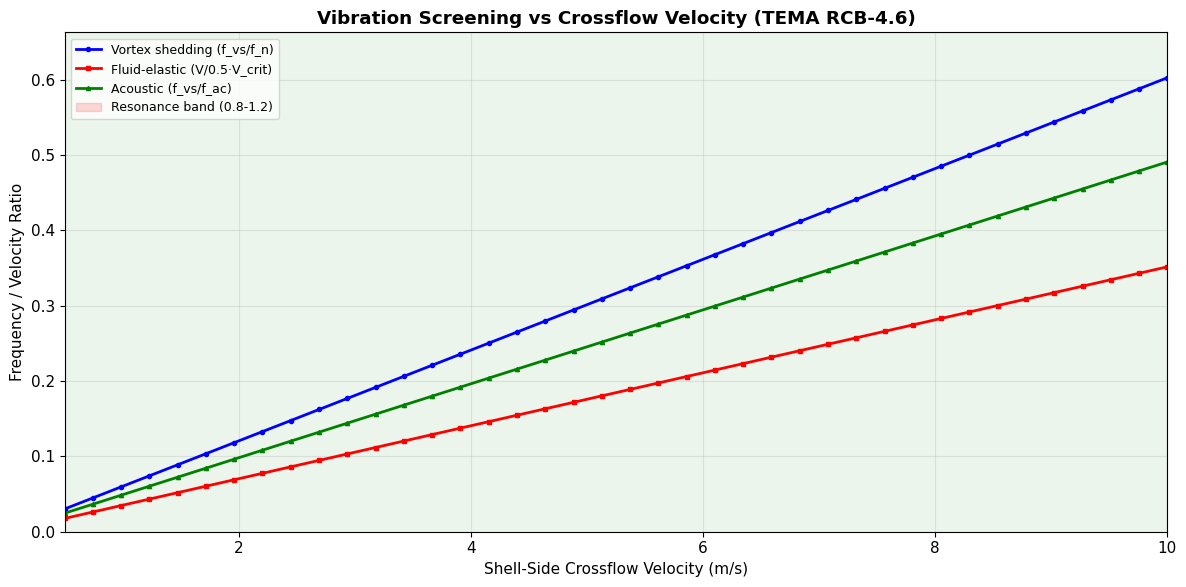


Maximum safe crossflow velocity: ~10.0 m/s


In [8]:
# Vibration screening for the base case
result = VibrationAnalysis.performScreening(
    0.01905,  # tube OD (m)
    0.01483,  # tube ID (m)
    0.4,      # unsupported span (m) - baffle spacing
    0.02381,  # tube pitch (m)
    200e9,    # Young's modulus (Pa) - carbon steel
    7800.0,   # tube material density (kg/m3)
    2.0,      # shell-side crossflow velocity (m/s)
    50.0,     # shell fluid density (kg/m3)
    800.0,    # tube fluid density (kg/m3)
    0.5,      # shell ID (m)
    340.0,    # sonic velocity in shell fluid (m/s)
    0.03,     # damping ratio
    True)     # triangular pitch

print("=" * 60)
print("VIBRATION SCREENING REPORT")
print("=" * 60)
print(str(result.getSummary()))

# Sweep crossflow velocity for vibration risk map
velocities = np.linspace(0.5, 10.0, 40)
vortex_ratios = []
fei_ratios = []
acoustic_ratios = []
pass_fail = []

for v in velocities:
    r = VibrationAnalysis.performScreening(
        0.01905, 0.01483, 0.4, 0.02381, 200e9, 7800.0,
        float(v), 50.0, 800.0, 0.5, 340.0, 0.03, True)
    vortex_ratios.append(float(r.vortexSheddingRatio))
    fei_ratios.append(float(r.velocityRatio))
    acoustic_ratios.append(float(r.acousticRatio))
    pass_fail.append(bool(r.passed))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(velocities, vortex_ratios, 'b-o', markersize=3, label='Vortex shedding (f_vs/f_n)', linewidth=2)
ax.plot(velocities, fei_ratios, 'r-s', markersize=3, label='Fluid-elastic (V/0.5·V_crit)', linewidth=2)
ax.plot(velocities, acoustic_ratios, 'g-^', markersize=3, label='Acoustic (f_vs/f_ac)', linewidth=2)

# Mark resonance / critical zones
ax.axhspan(0.8, 1.2, alpha=0.15, color='red', label='Resonance band (0.8-1.2)')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Mark pass/fail regions
max_safe_v = max([v for v, p in zip(velocities, pass_fail) if p], default=0)
if max_safe_v > 0:
    ax.axvspan(0.5, max_safe_v, alpha=0.08, color='green')
    ax.axvspan(max_safe_v, 10.0, alpha=0.08, color='red')

ax.set_xlabel('Shell-Side Crossflow Velocity (m/s)')
ax.set_ylabel('Frequency / Velocity Ratio')
ax.set_title('Vibration Screening vs Crossflow Velocity (TEMA RCB-4.6)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 10.0)
ax.set_ylim(0, max(max(vortex_ratios), max(fei_ratios), max(acoustic_ratios)) * 1.1)

plt.tight_layout()
plt.savefig("vibration_screening.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMaximum safe crossflow velocity: ~{max_safe_v:.1f} m/s")

### Discussion — Vibration Screening

**Observation:** Vortex shedding ratio scales linearly with crossflow velocity and is typically the first mechanism to trigger failure. Fluid-elastic instability follows a different curve and becomes critical at higher velocities. Acoustic resonance may enter the danger zone depending on shell geometry and sonic velocity.

**Physical mechanism:** As shell-side velocity increases, vortex shedding frequency rises linearly (f_vs = St·V/D). When f_vs approaches the tube natural frequency f_n (ratio 0.8–1.2), resonant vibration amplifies tube displacement, causing fatigue failure at tube support plates.

**Engineering implication:** The vibration screening determines the maximum allowable shell-side velocity, which constrains the minimum shell diameter and baffle spacing.

**Recommendation:** Keep all frequency ratios below 0.8 with adequate margin. If vortex shedding is critical, increase baffle spacing (raises f_n by reducing unsupported span) or increase tube pitch (reduces vortex energy).

## 7. Rating Mode — Process Simulation Integration

In **rating mode**, the `HeatExchanger` computes the overall U from the `ThermalDesignCalculator`
and the actual process stream properties, then calculates outlet temperatures for a fixed heat
transfer area. This demonstrates the full integration between thermal design and process simulation.

In [9]:
# Create a natural gas fluid
hot_fluid = SystemSrkEos(273.15 + 100.0, 20.0)
hot_fluid.addComponent("methane", 0.85)
hot_fluid.addComponent("ethane", 0.10)
hot_fluid.addComponent("propane", 0.05)
hot_fluid.setMixingRule("classic")

# Hot process gas stream
hot_stream = Stream("Hot Gas", hot_fluid)
hot_stream.setTemperature(100.0, "C")
hot_stream.setFlowRate(5000.0, "kg/hr")

# Cold cooling water (using same fluid type for simplicity)
cold_fluid = SystemSrkEos(273.15 + 20.0, 20.0)
cold_fluid.addComponent("methane", 0.85)
cold_fluid.addComponent("ethane", 0.10)
cold_fluid.addComponent("propane", 0.05)
cold_fluid.setMixingRule("classic")

cold_stream = Stream("Cold Water", cold_fluid)
cold_stream.setTemperature(20.0, "C")
cold_stream.setFlowRate(3000.0, "kg/hr")

# Create heat exchanger in RATING mode
hx = HeatExchanger("E-100", hot_stream, cold_stream)

# Configure rating calculator with exchanger geometry
rating_calc = ThermalDesignCalculator()
rating_calc.setTubeODm(0.01905)
rating_calc.setTubeIDm(0.01483)
rating_calc.setTubeLengthm(6.096)
rating_calc.setTubeCount(100)
rating_calc.setTubePasses(2)
rating_calc.setTubePitchm(0.02381)
rating_calc.setTriangularPitch(True)
rating_calc.setShellIDm(0.5)
rating_calc.setBaffleSpacingm(0.2)
rating_calc.setBaffleCount(10)
rating_calc.setBaffleCut(0.25)

hx.setRatingCalculator(rating_calc)
hx.setRatingArea(36.5)  # heat transfer area in m2

# Run process simulation
ps = ProcessSystem()
ps.add(hot_stream)
ps.add(cold_stream)
ps.add(hx)
ps.run()

print("=" * 60)
print("RATING MODE RESULTS")
print("=" * 60)
print(f"\nComputed U from correlations: {float(hx.getRatingU()):.1f} W/(m²·K)")
print(f"Rating area: {float(hx.getRatingArea()):.1f} m²")
print(f"\nHot side:  {float(hot_stream.getTemperature('C')):.1f}°C → {float(hx.getOutStream(0).getTemperature('C')):.1f}°C")
print(f"Cold side: {float(cold_stream.getTemperature('C')):.1f}°C → {float(hx.getOutStream(1).getTemperature('C')):.1f}°C")
print(f"\nHeat duty: {float(hx.getDuty()) / 1000.0:.1f} kW")

RATING MODE RESULTS

Computed U from correlations: 193.5 W/(m²·K)
Rating area: 36.5 m²

Hot side:  100.0°C → 57.9°C
Cold side: 20.0°C → 91.7°C

Heat duty: 137.8 kW


## 8. Full Mechanical Design with Thermal Integration

The complete mechanical design path automatically runs thermal calculations, selects exchanger type, and computes weights.

In [10]:
# Full mechanical design with process simulation
HeatExchangerMechanicalDesign = jpype.JClass(
    "neqsim.process.mechanicaldesign.heatexchanger.HeatExchangerMechanicalDesign")

fluid2 = SystemSrkEos(273.15 + 60.0, 20.0)
fluid2.addComponent("methane", 120.0)
fluid2.addComponent("ethane", 120.0)
fluid2.addComponent("n-heptane", 3.0)
fluid2.createDatabase(True)
fluid2.setMixingRule(2)

hot2 = Stream("hot feed", fluid2)
hot2.setTemperature(100.0, "C")
hot2.setFlowRate(1000.0, "kg/hr")

cold2 = Stream("cold feed", fluid2.clone())
cold2.setTemperature(20.0, "C")
cold2.setFlowRate(310.0, "kg/hr")

hx2 = HeatExchanger("E-200", hot2, cold2)
hx2.setUAvalue(1000.0)

ps2 = ProcessSystem()
ps2.add(hot2)
ps2.add(cold2)
ps2.add(hx2)
ps2.run()

# Run full mechanical design
hx2.initMechanicalDesign()
design = hx2.getMechanicalDesign()
design.calcDesign()

print("=" * 60)
print("FULL MECHANICAL DESIGN RESULTS")
print("=" * 60)
selected = design.getSelectedSizingResult()
sel_type = design.getSelectedType()
print(f"\nSelected exchanger type: {sel_type.getDisplayName() if sel_type else 'N/A'}")
if selected is not None:
    print(f"Required area: {float(selected.getRequiredArea()):.2f} m²")
    print(f"Estimated weight: {float(selected.getEstimatedWeight()):.0f} kg")
    print(f"Shell inner diameter: {float(selected.getInnerDiameter()) * 1000:.0f} mm")
    print(f"Tube count: {int(selected.getTubeCount())}")
    print(f"Tube length: {float(selected.getEstimatedLength()):.2f} m")
    print(f"U overall: {float(selected.getOverallHeatTransferCoefficient()):.1f} W/(m²·K)")

# Show all sizing options
print(f"\n--- All TEMA Type Sizing Options ---")
all_results = design.getSizingResults()
sizing_data = []
for sr in all_results:
    sizing_data.append({
        'TEMA Type': str(sr.getType().getDisplayName()),
        'Area (m²)': f"{float(sr.getRequiredArea()):.2f}",
        'U (W/m²K)': f"{float(sr.getOverallHeatTransferCoefficient()):.1f}",
        'Weight (kg)': f"{float(sr.getEstimatedWeight()):.0f}",
        'Shell ID (mm)': f"{float(sr.getInnerDiameter()) * 1000:.0f}",
        'Tubes': int(sr.getTubeCount()),
        'Length (m)': f"{float(sr.getEstimatedLength()):.2f}"
    })

df_sizing = pd.DataFrame(sizing_data)
print(df_sizing.to_string(index=False))

# Print mechanical design summary
print(f"\n--- Design Summary ---")
print(design.getSizingSummary())

FULL MECHANICAL DESIGN RESULTS

Selected exchanger type: Plate and frame
Required area: 0.87 m²
Estimated weight: 132 kg
Shell inner diameter: 526 mm
Tube count: 11
Tube length: 0.63 m
U overall: 1150.0 W/(m²·K)

--- All TEMA Type Sizing Options ---
       TEMA Type Area (m²) U (W/m²K) Weight (kg) Shell ID (mm)  Tubes Length (m)
  Shell and tube      1.72     580.0         533           300      5       6.00
 Plate and frame      0.87    1150.0         132           526     11       0.63
      Air cooled     11.11      90.0         225          2523      0       2.24
     Double pipe      2.86     350.0         247            50      2      18.19
Plate-fin (BAHX)      1.67     600.0           1            65      0       0.39

--- Design Summary ---
Shell and tube: area=1.72 m2, weight=532.7 kg; Plate and frame: area=0.87 m2, weight=132.0 kg; Air cooled: area=11.11 m2, weight=225.0 kg; Double pipe: area=2.86 m2, weight=246.7 kg; Plate-fin (BAHX): area=1.67 m2, weight=1.4 kg


## 9. Thermal Resistance Breakdown

Understanding which resistance dominates the overall U is essential for design optimization. Let's compute and visualize the resistance contributions for different services.

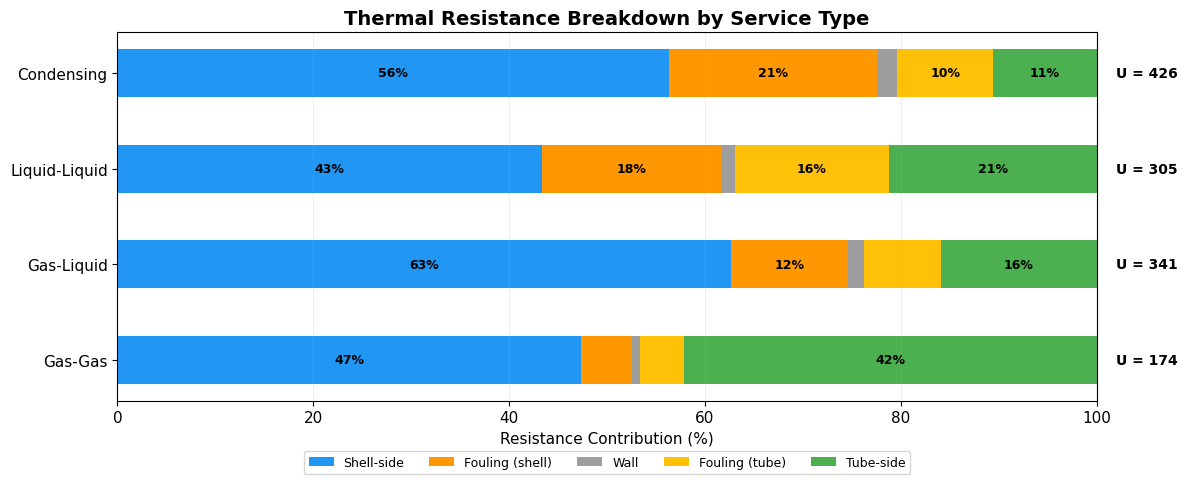


Overall U by Service Type:
  Gas-Gas          U =    174.3 W/(m²·K)
  Gas-Liquid       U =    340.5 W/(m²·K)
  Liquid-Liquid    U =    304.8 W/(m²·K)
  Condensing       U =    425.8 W/(m²·K)


In [11]:
# Thermal resistance breakdown for different services
services = {
    'Gas-Gas': {
        'tube': (20.0, 2.0e-5, 1100.0, 0.025, 2.0, True),
        'shell': (30.0, 1.8e-5, 1200.0, 0.028, 2.5),
        'foul_t': 0.0002, 'foul_s': 0.0003
    },
    'Gas-Liquid': {
        'tube': (998.0, 0.001, 4180.0, 0.60, 5.0, True),
        'shell': (50.0, 1.5e-5, 2200.0, 0.03, 3.0),
        'foul_t': 0.00018, 'foul_s': 0.00035
    },
    'Liquid-Liquid': {
        'tube': (800.0, 0.0005, 2500.0, 0.12, 8.0, True),
        'shell': (850.0, 0.001, 2100.0, 0.10, 6.0),
        'foul_t': 0.0004, 'foul_s': 0.0006
    },
    'Condensing': {
        'tube': (998.0, 0.001, 4180.0, 0.60, 10.0, True),
        'shell': (600.0, 0.0002, 2800.0, 0.08, 4.0),
        'foul_t': 0.00018, 'foul_s': 0.0005
    }
}

# Geometry constants
do, di = 0.01905, 0.01483
kw = 50.0  # tube wall conductivity W/(m·K)

resistance_data = []

for name, svc in services.items():
    c = ThermalDesignCalculator()
    c.setTubeODm(do); c.setTubeIDm(di); c.setTubeLengthm(6.096)
    c.setTubeCount(100); c.setTubePasses(2); c.setTubePitchm(0.02381)
    c.setTriangularPitch(True); c.setShellIDm(0.5)
    c.setBaffleSpacingm(0.2); c.setBaffleCount(10); c.setBaffleCut(0.25)
    c.setTubeWallConductivity(kw)
    c.setTubeSideFluid(*svc['tube'])
    c.setShellSideFluid(*svc['shell'])
    c.setFoulingTube(svc['foul_t'])
    c.setFoulingShell(svc['foul_s'])
    c.calculate()

    ht = float(c.getTubeSideHTC())
    hs = float(c.getShellSideHTC())
    U = float(c.getOverallU())

    # Compute individual resistances
    import math
    R_shell = 1.0 / hs if hs > 0 else 0
    R_foul_shell = svc['foul_s']
    R_wall = do * math.log(do / di) / (2.0 * kw)
    R_foul_tube = svc['foul_t'] * (do / di)
    R_tube = (1.0 / ht) * (do / di) if ht > 0 else 0
    R_total = R_shell + R_foul_shell + R_wall + R_foul_tube + R_tube

    resistance_data.append({
        'Service': name,
        'Shell-side': R_shell / R_total * 100,
        'Fouling (shell)': R_foul_shell / R_total * 100,
        'Wall': R_wall / R_total * 100,
        'Fouling (tube)': R_foul_tube / R_total * 100,
        'Tube-side': R_tube / R_total * 100,
        'U (W/m²K)': U
    })

df_res = pd.DataFrame(resistance_data)

# Stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 5))
categories = ['Shell-side', 'Fouling (shell)', 'Wall', 'Fouling (tube)', 'Tube-side']
colors = ['#2196F3', '#FF9800', '#9E9E9E', '#FFC107', '#4CAF50']

left = np.zeros(len(df_res))
for cat, col in zip(categories, colors):
    ax.barh(df_res['Service'], df_res[cat], left=left, color=col, label=cat, height=0.5)
    # Add percentage labels for significant contributions
    for i, (val, l) in enumerate(zip(df_res[cat], left)):
        if val > 8:
            ax.text(l + val/2, i, f'{val:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    left += df_res[cat].values

ax.set_xlabel('Resistance Contribution (%)')
ax.set_title('Thermal Resistance Breakdown by Service Type', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, fontsize=9)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.2, axis='x')

# Add U values on the right
for i, row in df_res.iterrows():
    ax.text(102, i, f"U = {row['U (W/m²K)']:.0f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("resistance_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print("\nOverall U by Service Type:")
for _, row in df_res.iterrows():
    print(f"  {row['Service']:15s}  U = {row['U (W/m²K)']:>8.1f} W/(m²·K)")

### Discussion — Resistance Breakdown

**Observation:** Gas-gas exchangers are dominated by both film resistances — the gas-side HTCs are low (typically 20-80 W/m²K) so the controlling resistance is the gas HTC on both sides. Liquid-liquid exchangers have higher overall U but fouling becomes a significant fraction of total resistance.

**Physical mechanism:** Gas has ~100× lower thermal conductivity than liquid, so convective HTC for gas (h ∝ k/D × Re^0.8 × Pr^0.33) is orders of magnitude lower. Fouling deposits act as additional insulating layers with fixed thermal resistance.

**Engineering implication:** For gas services, use finned tubes or increase velocity. For liquid services, manage fouling through regular cleaning schedules and appropriate material selection.

**Recommendation:** Focus optimization efforts on the dominant resistance. For gas coolers, increasing gas velocity has the highest impact on U. For liquid-liquid exchangers, fouling control is more important than geometry changes.

## Summary

This notebook demonstrated the full thermal-hydraulic design capability of NeqSim for shell-and-tube heat exchangers:

| Feature | Demonstrated |
|---------|-------------|
| **Standalone thermal calculation** | Section 1 — ThermalDesignCalculator with geometry and fluid inputs |
| **Method comparison** | Section 2 — Kern vs Bell-Delaware across flow rates |
| **LMTD correction** | Section 3 — Ft charts and required shell passes |
| **Geometry sensitivity** | Section 4 — Tube count effect on U, velocity, ΔP |
| **J-factor analysis** | Section 5 — All five Bell-Delaware correction factors |
| **Vibration screening** | Section 6 — TEMA RCB-4.6 with velocity sweep |
| **Rating mode** | Section 7 — Process simulation with computed U |
| **Full mechanical design** | Section 8 — Automated type selection and sizing |
| **Resistance breakdown** | Section 9 — Dominant resistance identification |

### Key API Entry Points

- `ThermalDesignCalculator` — standalone thermal-hydraulic calculations
- `BellDelawareMethod` — shell-side correlation library
- `LMTDcorrectionFactor` — multi-pass correction factors
- `VibrationAnalysis` — TEMA vibration screening
- `HeatExchanger.setRatingCalculator()` — process simulation rating mode
- `HeatExchangerMechanicalDesign.calcDesign()` — full mechanical design path

### Related Documentation

- [Thermal-Hydraulic Design Guide](../../docs/process/mechanical_design/thermal_hydraulic_design.md)
- [TEMA Standard Guide](../../docs/process/mechanical_design/tema_standard_guide.md)
- [Heat Exchanger Equipment](../../docs/process/equipment/heat_exchangers.md)